In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

ret = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)["^GSPC"]
print(ret.describe())
print(f"Skew: {stats.skew(ret):.3f}, Kurtosis: {stats.kurtosis(ret):.3f}")

count    2515.000000
mean        0.041750
std         1.126972
min       -12.765220
25%        -0.378326
50%         0.063567
75%         0.573850
max         8.968323
Name: ^GSPC, dtype: float64
Skew: -0.810, Kurtosis: 15.721


Figure 1 — return series:

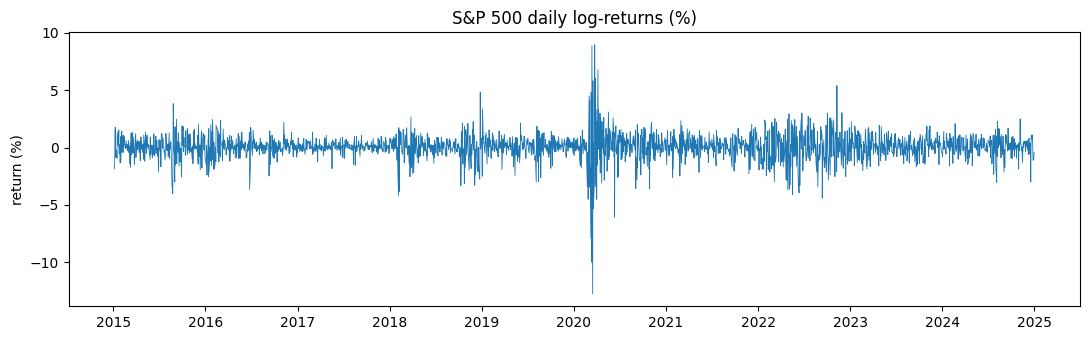

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(ret.index, ret, lw=0.6)
ax.set_title("S&P 500 daily log-returns (%)")
ax.set_ylabel("return (%)")
plt.tight_layout()
plt.savefig("../figures/eda_returns.png", dpi=150)
plt.show()

Figure 2 — histogram + QQ plot:

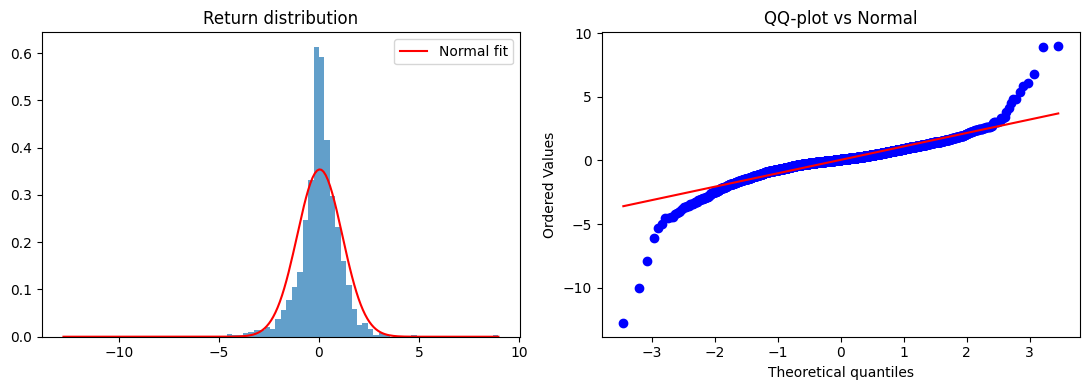

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(ret, bins=80, density=True, alpha=0.7)
x = np.linspace(ret.min(), ret.max(), 200)
axes[0].plot(x, stats.norm.pdf(x, ret.mean(), ret.std()), 'r-', lw=1.5, label="Normal fit")
axes[0].set_title("Return distribution")
axes[0].legend()
stats.probplot(ret, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot vs Normal")
plt.tight_layout()
plt.savefig("../figures/eda_distribution.png", dpi=150)
plt.show()

Figure 3 — ACF of returns and squared returns:

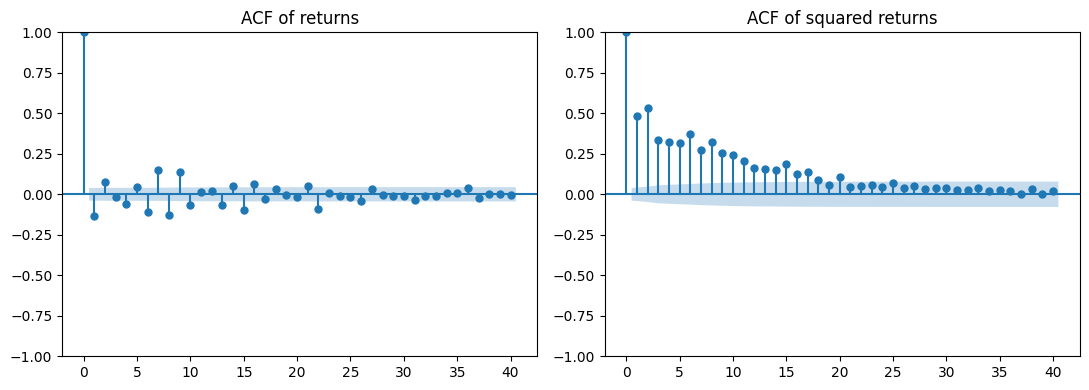

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_acf(ret, lags=40, ax=axes[0])
axes[0].set_title("ACF of returns")
plot_acf(ret**2, lags=40, ax=axes[1])
axes[1].set_title("ACF of squared returns")
plt.tight_layout()
plt.savefig("../figures/eda_acf.png", dpi=150)
plt.show()